# Анализ рынка компьютерных игр

Вы работаете в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). 

### Цель проекта
Нужно **выявить определяющие успешность игры закономерности**. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

### Описание данных

Данные до 2016 года. Данные за 2016 год могут быть неполными.

В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

* Name — название игры
* Platform — платформа
* Year_of_Release — год выпуска
* Genre — жанр игры
* NA_sales — продажи в Северной Америке (миллионы проданных копий)
* EU_sales — продажи в Европе (миллионы проданных копий)
* JP_sales — продажи в Японии (миллионы проданных копий)
* Other_sales — продажи в других странах (миллионы проданных копий)
* Critic_Score — оценка критиков (максимум 100)
* User_Score — оценка пользователей (максимум 10)
* Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.


## Общая информация

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st

In [2]:
data = pd.read_csv('games.csv')
data.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


In [4]:
data.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [5]:
data.duplicated().sum()

np.int64(0)

Явных дубликатов в данных не обнаружено.

## Подготовка данных

#### Замена названий столбцов

In [6]:
data.columns = data.columns.str.lower()
data.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')

In [7]:
data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### Преобразование данных в нужные типы

In [8]:
data.dtypes

name                   str
platform               str
year_of_release    float64
genre                  str
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score             str
rating                 str
dtype: object

In [9]:
data['year_of_release'] = data['year_of_release'].astype('Int64') 
data['year_of_release'] 

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16710    2016
16711    2006
16712    2016
16713    2003
16714    2016
Name: year_of_release, Length: 16715, dtype: Int64

Значение 'tbd' означает "to be determined", то есть оценка отсутствует.
Эти значения были заменены на NaN, так как они не являются числовыми и искажают статистические расчёты.

In [10]:
data.loc[data['user_score']=='tbd', 'user_score'] = np.nan
data['user_score'] = data['user_score'].astype('float') 
data['user_score']

0        8.0
1        NaN
2        8.3
3        8.0
4        NaN
        ... 
16710    NaN
16711    NaN
16712    NaN
16713    NaN
16714    NaN
Name: user_score, Length: 16715, dtype: float64

In [11]:
data.dtypes

name                   str
platform               str
year_of_release      Int64
genre                  str
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating                 str
dtype: object

#### Обработка пропусков

In [12]:
data.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [13]:
data[data['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [14]:
data[data['genre'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


В датасете обнаружены 2 строки, одновременно содержащие пропуски в name и genre. Так как восстановить эти значения невозможно, а количество таких строк незначительно относительно общего объёма данных, удалим их.

In [15]:
data = data.dropna(subset=['name', 'genre'])

In [16]:
data[data['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,<NA>,Sports,0.01,0.00,0.00,0.00,43.0,NaN,E10+
16405,Freaky Flyers,GC,<NA>,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,<NA>,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,<NA>,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [17]:
round(data['year_of_release'].isna().sum() / data.shape[0] * 100, 2)

np.float64(1.61)

Пропуски в year_of_release составляют около 1.6% данных. Надёжно восстановить год выпуска невозможно, поэтому пропуски оставляем без заполнения. Эти записи автоматически не попадут в анализ по годам.

In [18]:
data[data['critic_score'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [19]:
data.groupby('year_of_release')['critic_score'].agg(
    non_nan='count',
    nan=lambda x: x.isna().sum()
)

,non_nan,nan
year_of_release,,
1980,0,9
1981,0,46
1982,0,36
1983,0,17
1984,0,14
1985,1,13
1986,0,21
1987,0,16
1988,1,14


In [20]:
data[data['user_score'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [21]:
data.groupby('year_of_release')['user_score'].agg(
    non_nan='count',
    nan=lambda x: x.isna().sum()
)

,non_nan,nan
year_of_release,,
1980,0,9
1981,0,46
1982,0,36
1983,0,17
1984,0,14
1985,1,13
1986,0,21
1987,0,16
1988,1,14


Пропуски в оценках критиков и пользователей могут возникать по нескольким причинам:

* игра не получила достаточного количества оценок;
* игра вышла недавно на момент формирования базы;
* данные не были собраны источником;
* для части старых игр рейтинги отсутствуют.

Заполнять такие пропуски средними или медианами нельзя, поскольку это исказит реальные оценки.

In [22]:
data[data['rating'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [23]:
data.groupby('year_of_release')['rating'].agg(
    non_nan='count',
    nan=lambda x: x.isna().sum()
)

,non_nan,nan
year_of_release,,
1980,0,9
1981,0,46
1982,0,36
1983,0,17
1984,0,14
1985,1,13
1986,0,21
1987,0,16
1988,1,14


In [24]:
data['rating'] = data['rating'].fillna('no rating')

В столбце rating содержится значительное количество пропусков. Они могут быть связаны с тем, что часть игр не получила рейтинг ESRB, рейтинг отсутствовал в исходном источнике данных или игра выпускалась на рынках, где данная система возрастной классификации не использовалась.

Заполнять пропуски существующей категорией рейтинга нельзя, поскольку это исказит результаты анализа. Поэтому пропуски были заменены на отдельную категорию 'no rating', которая позволяет сохранить все наблюдения и учитывать отсутствие рейтинга как самостоятельную характеристику игры.

In [25]:
data.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating                0
dtype: int64

#### Суммарные продажи

In [26]:
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']
data['total_sales']

0        82.54
1        40.24
2        35.52
3        32.77
4        31.38
         ...  
16710     0.01
16711     0.01
16712     0.01
16713     0.01
16714     0.01
Name: total_sales, Length: 16713, dtype: float64

## Исследовательский анализ данных

#### Сколько игр выпускалось в разные годы

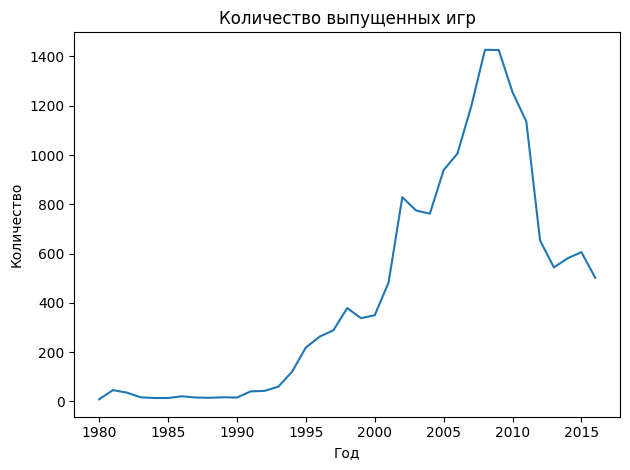

In [27]:
data['year_of_release'].value_counts().sort_index().plot()

plt.xlabel('Год')
plt.ylabel('Количество')
plt.title('Количество выпущенных игр')

plt.tight_layout()

До середины 1990-х годов количество выпускаемых игр было небольшим. Далее наблюдается устойчивый рост, который достигает максимума в 2008–2009 годах. После 2010 года количество релизов начинает снижаться.

#### Как менялись продажи по платформам

In [28]:
heatmap_data = data.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')

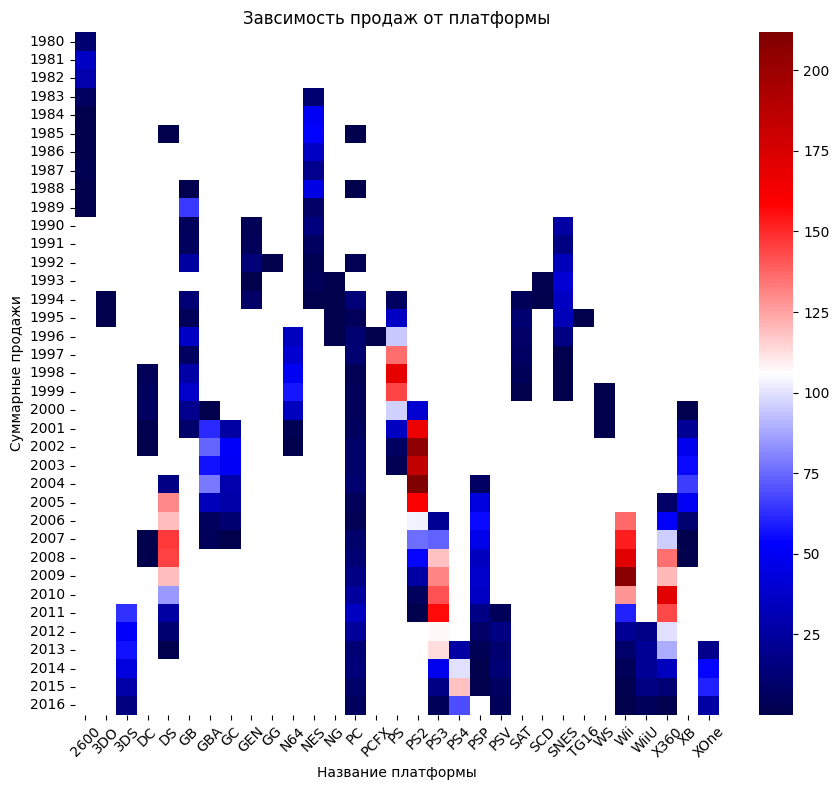

In [29]:
plt.figure(figsize=(9, 8))
sns.heatmap(heatmap_data, cmap='seismic')

plt.xticks(rotation = 45)
plt.xlabel('Название платформы')
plt.ylabel('Суммарные продажи')
plt.title('Завсимость продаж от платформы')

plt.tight_layout()

Большинство платформ демонстрируют активный жизненный цикл продолжительностью примерно 7–10 лет: после периода роста продажи достигают пика и затем постепенно снижаются.

Также заметно, что начиная с 2013 года на рынке появляется новое поколение платформ.

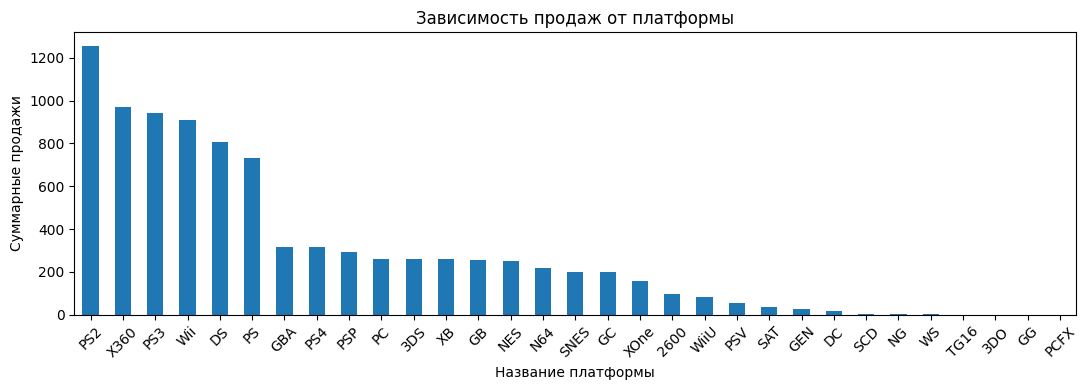

In [30]:
plt.figure(figsize=(11, 4))
data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).plot(kind='bar')

plt.xticks(rotation = 45)
plt.xlabel('Название платформы')
plt.ylabel('Суммарные продажи')
plt.title('Зависимость продаж от платформы')
plt.tight_layout()

Наибольшие продажи демонстрировали платформы PS2, X360, PS3, Wii и DS. 

In [31]:
top_5 = data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).index[:5]
top_5

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='str', name='platform')

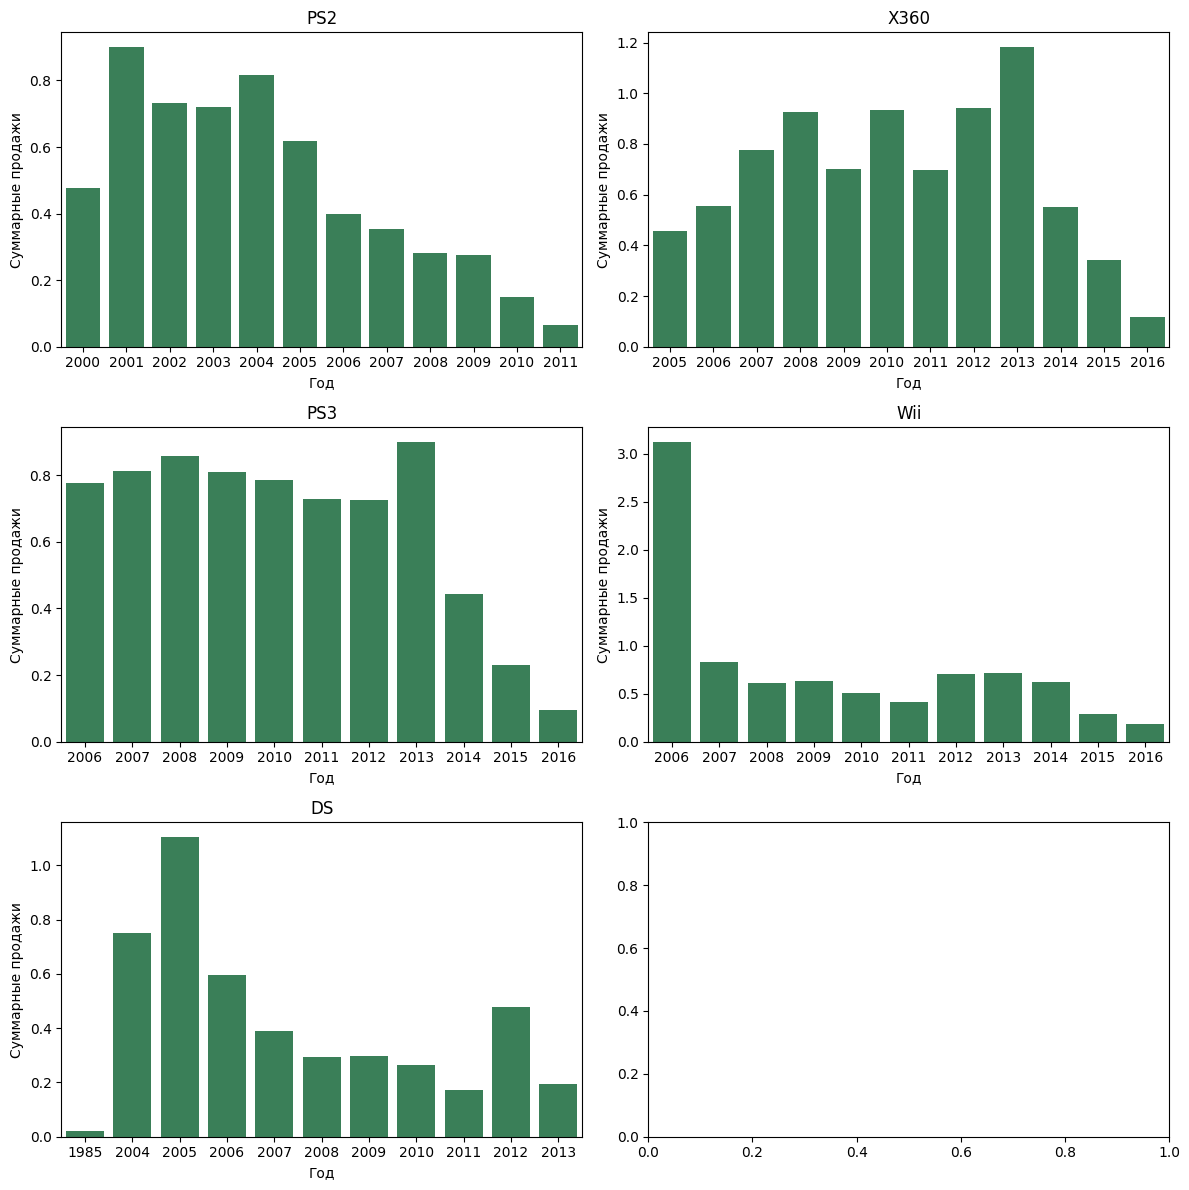

In [32]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))  # 3 ряда, 2 колонки
ax = ax.flatten()  # превращаем сетку в плоский список для удобного индекса

for i, p in enumerate(top_5):
    df = data[data['platform'] == p]
    
    sns.barplot(data=df, x='year_of_release', y='total_sales', errorbar=None, ax=ax[i], color='seagreen')

    ax[i].set_xlabel('Год')
    ax[i].set_ylabel('Суммарные продажи')
    ax[i].set_title(p)

plt.tight_layout()


#### Данные за актуальный период

Выделим актуальный период. Основной фактор — эти данные помогут построить прогноз на 2017 год.

Для прогноза на 2017 год наиболее важны последние тенденции рынка. Использование слишком старых данных может исказить выводы, поскольку за это время меняются платформы, предпочтения игроков и структура рынка.

После анализа динамики продаж видно, что начиная примерно с 2013 года сформировалось новое поколение платформ (PS4, XOne и др.), поэтому для дальнейшего анализа используем данные за 2013–2016 годы.

In [33]:
all_data = data.copy()

data = data.query('2013 <= year_of_release <= 2016')

#### Какие платформы лидируют по продажам, растут или падают?

In [34]:
data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

Выберем несколько потенциально прибыльных платформ.

In [35]:
top_5 = data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).index[:5]

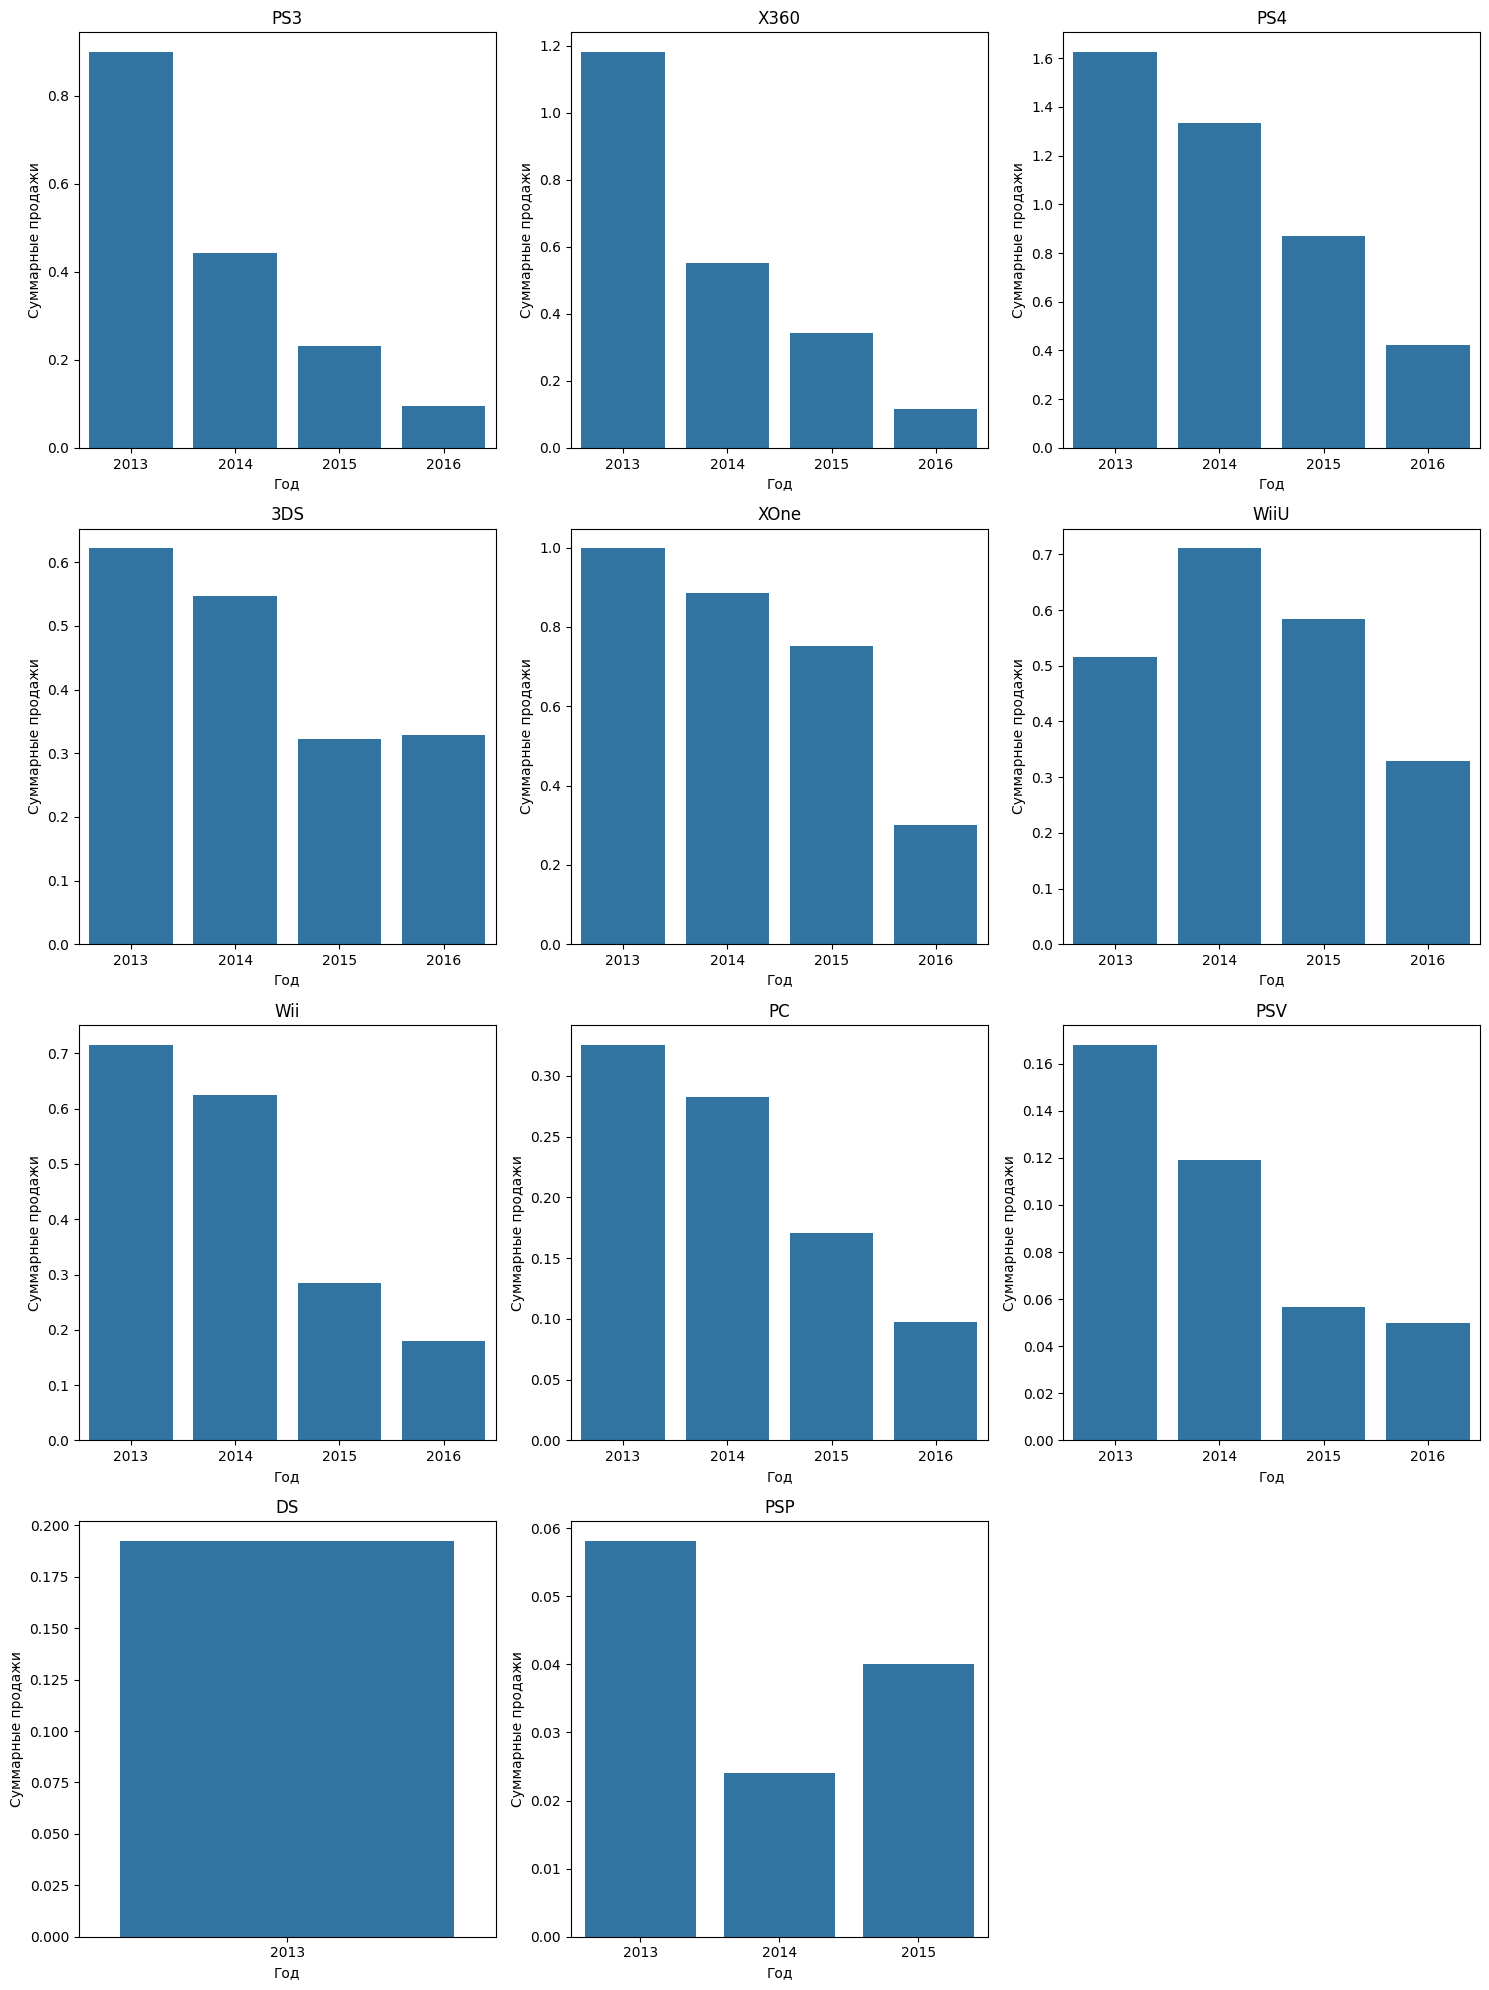

In [36]:
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))  
ax = ax.flatten() 

for i, p in enumerate(data['platform'].unique()):
    df = data[data['platform'] == p]
    
    sns.barplot(data=df, x='year_of_release', y='total_sales', errorbar=None, ax=ax[i])

    ax[i].set_xlabel('Год')
    ax[i].set_ylabel('Суммарные продажи')
    ax[i].set_title(p)

# скрываем лишние графики
for j in range(len(data['platform'].unique()), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()

Среди актуальных платформ наибольший интерес представляют PS4 и XOne. Они сохраняют высокие продажи в последние годы исследуемого периода и относятся к новому поколению игровых платформ. Это делает их наиболее перспективными для планирования продаж на 2017 год.

#### Boxplot по глобальным продажам игр в разбивке по платформам

Для каждой платформы есть единичные выбросы, игры с рекордными продажами. Такие игры влияют на средние показатели продаж, смещая их вверх. Ограничим ось Y для построения графика. 

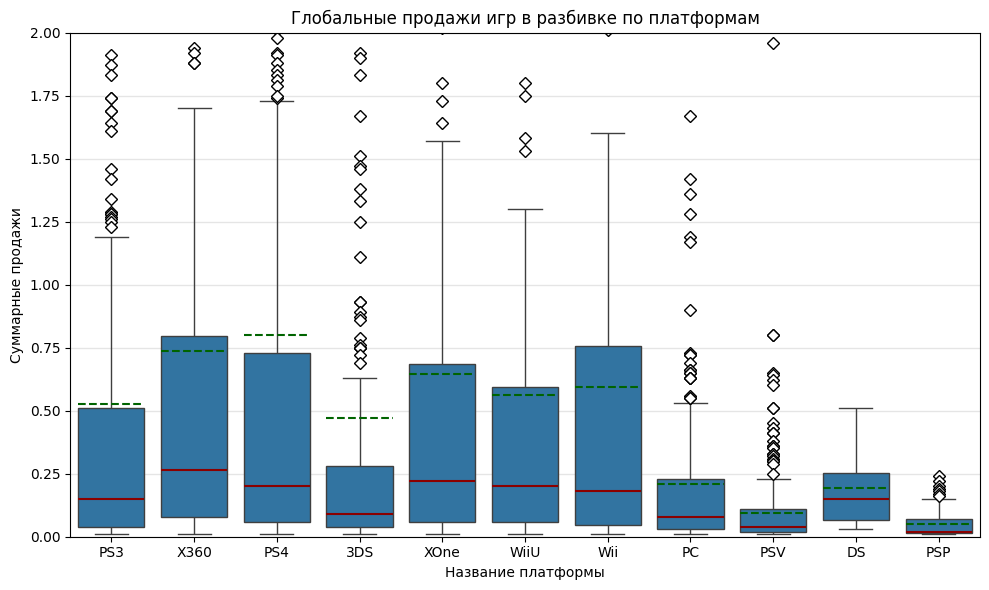

In [37]:
plt.figure(figsize=(10,6))
plt.grid(which='major', linewidth=1, color='gray', alpha=0.2)

sns.boxplot(x='platform', y='total_sales', data=data,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'darkgreen', 'linewidth': 1.5},
            medianprops={'color': 'darkred', 'linewidth': 1.5},
            flierprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor':'black'},
            ).set(ylim=(0, 2))

plt.title('Глобальные продажи игр в разбивке по платформам')
plt.xlabel('Название платформы')
plt.ylabel('Суммарные продажи')

plt.tight_layout()


Для большинства платформ характерно наличие большого количества выбросов, что говорит о существовании отдельных игр-бестселлеров. В данной выборке больше всего таких игр у платформ PS4 и X360. Медианные продажи заметно ниже максимальных значений, поэтому рынок игр можно считать высоко концентрированным: основную часть продаж обеспечивают относительно немногие успешные проекты.

#### Как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков

Проведем анализ на примере PS4. Построим диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами

In [38]:
df = data.loc[data.platform == 'PS4']

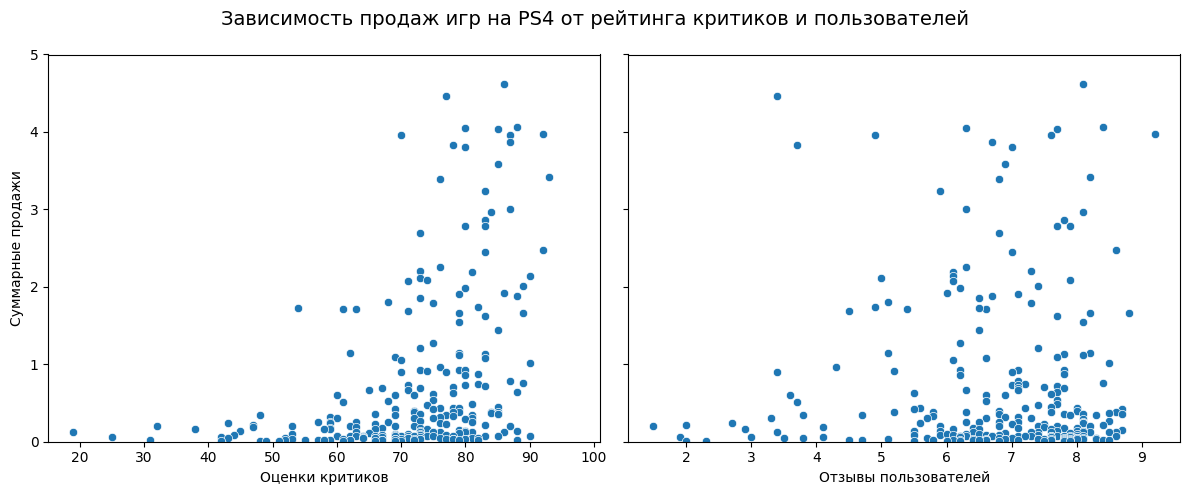

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.scatterplot(data=df, x='critic_score', y='total_sales', ax=ax[0]).set_ylim(0,5)
sns.scatterplot(data=df, x='user_score', y='total_sales', ax=ax[1])

ax[0].set_xlabel('Оценки критиков')
ax[0].set_ylabel('Суммарные продажи')
ax[1].set_xlabel('Оценки пользователей')
plt.xlabel('Отзывы пользователей')
plt.suptitle('Зависимость продаж игр на PS4 от рейтинга критиков и пользователей', fontsize=14)

plt.tight_layout()

In [40]:
print('Корреляция между оценками критиков и продажами для PS4:', round(df['critic_score'].corr(df['total_sales']),2))
print('Корреляция между оценками пользователей и продажами для PS4:', round(df['user_score'].corr(df['total_sales']),2))

Корреляция между оценками критиков и продажами для PS4: 0.41
Корреляция между оценками пользователей и продажами для PS4: -0.03


Коэффициент корреляции между пользовательскими оценками и продажами близок к нулю, что говорит об отсутствии заметной линейной связи. Корреляция между оценками критиков и продажами умеренно положительная, поэтому высокие оценки критиков чаще сопровождаются более высокими продажами.

#### Соотнесем выводы с продажами игр на других платформах

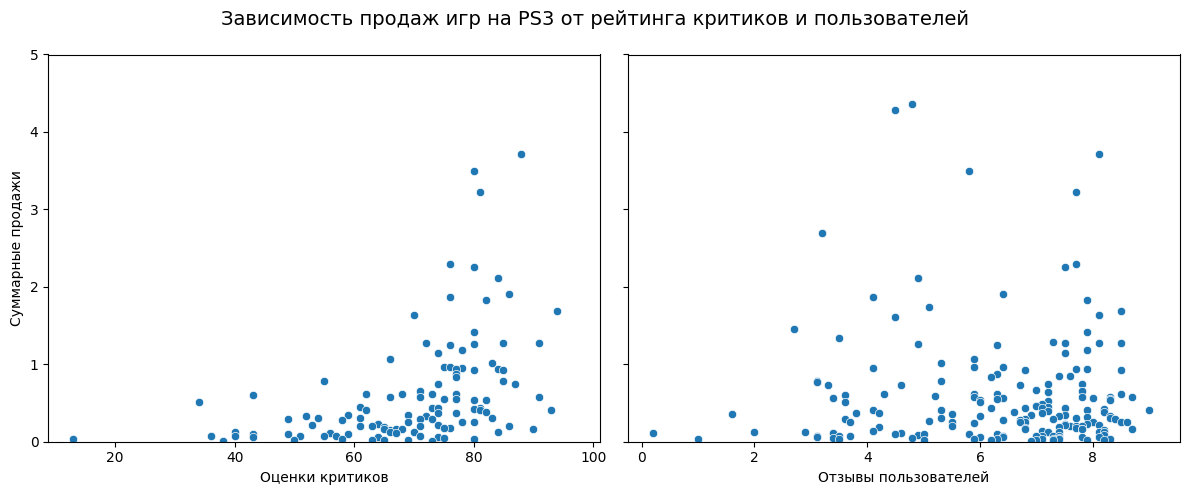

Корреляция между оценками критиков и продажами для PS3: 0.33
Корреляция между оценками пользователей и продажами для PS3: 0.0


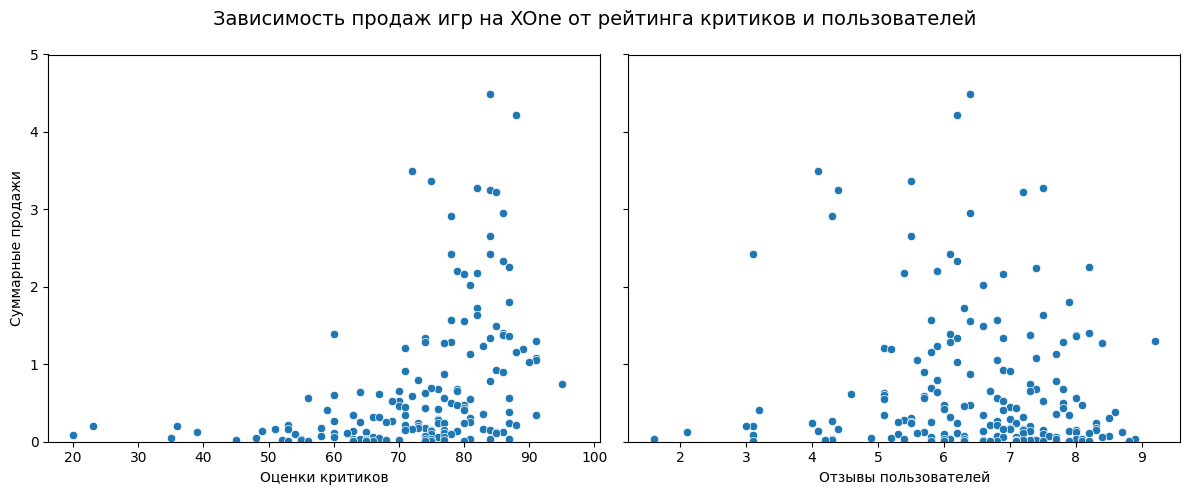

Корреляция между оценками критиков и продажами для XOne: 0.42
Корреляция между оценками пользователей и продажами для XOne: -0.07


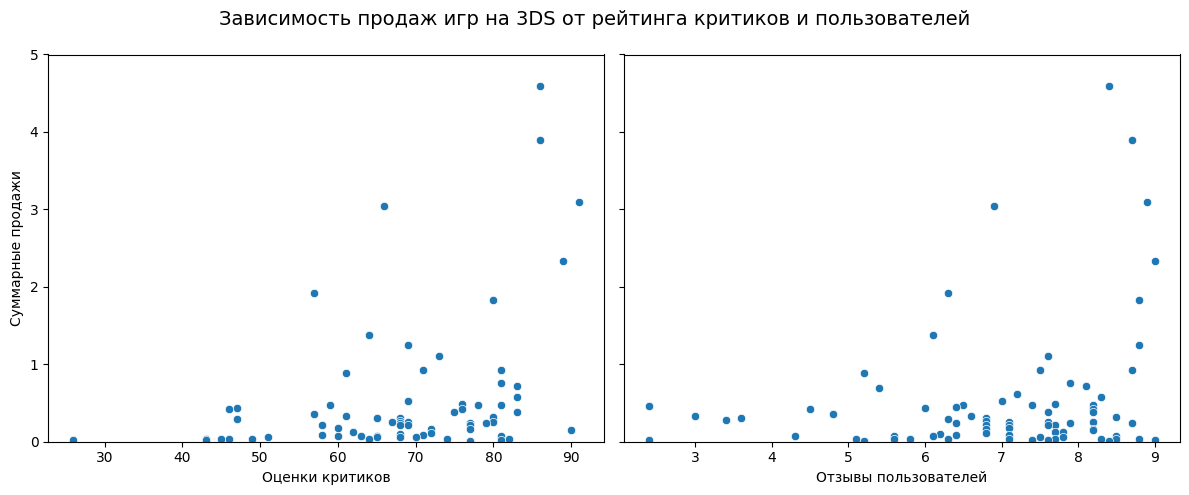

Корреляция между оценками критиков и продажами для 3DS: 0.36
Корреляция между оценками пользователей и продажами для 3DS: 0.24


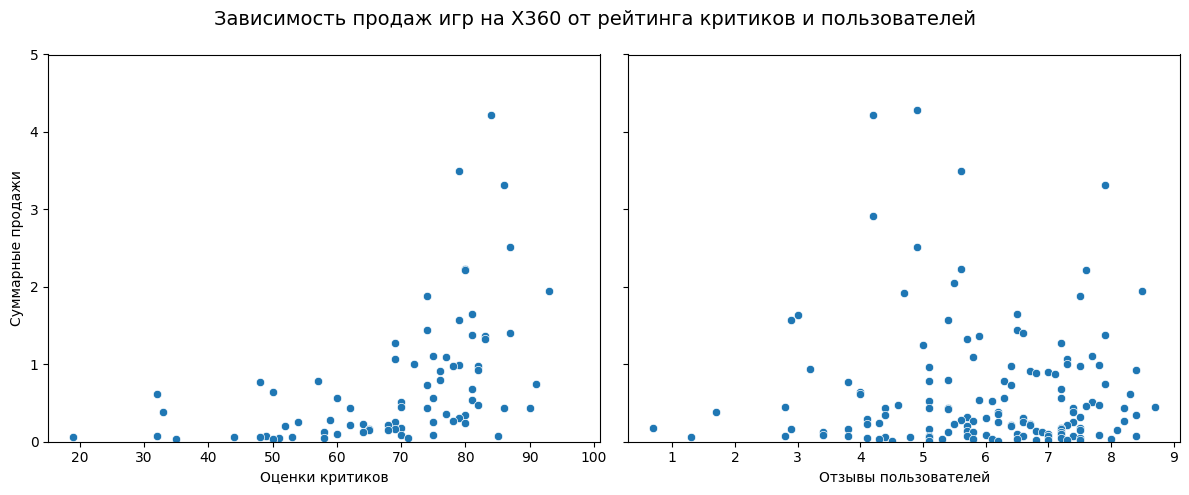

Корреляция между оценками критиков и продажами для X360: 0.35
Корреляция между оценками пользователей и продажами для X360: -0.01


In [41]:
for plat in top_5[1:]:
    df = data.loc[data.platform == plat]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.scatterplot(data=df, x='critic_score', y='total_sales', ax=ax[0]).set_ylim(0,5)
    sns.scatterplot(data=df, x='user_score', y='total_sales', ax=ax[1])

    ax[0].set_xlabel('Оценки критиков')
    ax[0].set_ylabel('Суммарные продажи')
    ax[1].set_xlabel('Оценки пользователей')
    plt.xlabel('Отзывы пользователей')
    plt.suptitle(f'Зависимость продаж игр на {plat} от рейтинга критиков и пользователей', fontsize=14)

    plt.tight_layout()
    plt.show()

    print(f'Корреляция между оценками критиков и продажами для {plat}:', round(df['critic_score'].corr(df['total_sales']),2))
    print(f'Корреляция между оценками пользователей и продажами для {plat}:', round(df['user_score'].corr(df['total_sales']),2))

Сильной зависимости между пользовательскими оценками и продажами не обнаружено.
Оценки критиков оказывают более заметное влияние на продажи, но связь остаётся умеренной.

#### Общее распределение игр по жанрам

Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

Рассмотрим и суммарные продажи и медианные, так как жанр может иметь большие суммарные продажи просто потому, что игр много.

In [42]:
genres_df = data.groupby('genre')['total_sales'].agg(['sum', 'median']).reset_index()

genres_df.style.format({'sum': '{:.1f}', 'median': '{:.2f}'})\
                            .background_gradient(subset=['sum', 'median'], cmap='Greens')

,genre,sum,median
0,Action,321.9,0.11
1,Adventure,23.6,0.03
2,Fighting,35.3,0.12
3,Misc,62.8,0.10
4,Platform,42.6,0.22
5,Puzzle,3.2,0.06
6,Racing,39.9,0.12
7,Role-Playing,145.9,0.12
8,Shooter,233.0,0.45
9,Simulation,21.8,0.10


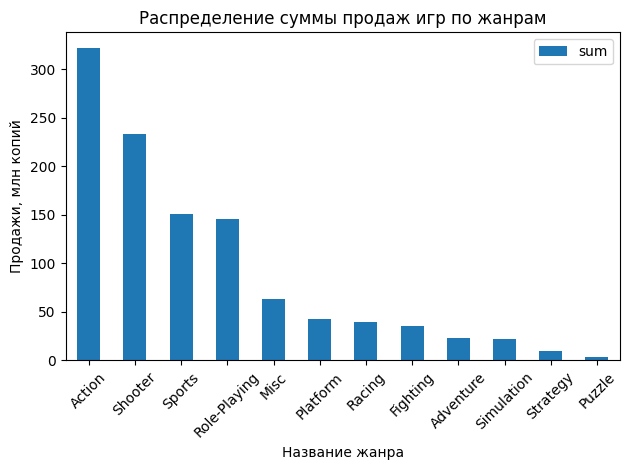

In [43]:
genres_df[['genre', 'sum']].sort_values(by='sum', ascending=False)\
                                    .plot(x='genre', y='sum', kind='bar')

plt.title('Распределение суммы продаж игр по жанрам')
plt.ylabel('Продажи, млн копий')
plt.xlabel('Название жанра')
plt.xticks(rotation = 45)

plt.tight_layout()

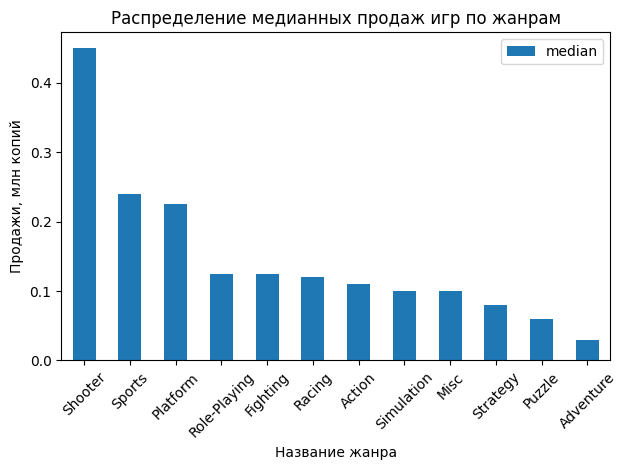

In [44]:
genres_df[['genre', 'median']].sort_values(by='median', ascending=False)\
                                    .plot(x='genre', y='median', kind='bar')

plt.title('Распределение медианных продаж игр по жанрам')
plt.ylabel('Продажи, млн копий')
plt.xlabel('Название жанра')
plt.xticks(rotation = 45)

plt.tight_layout()

Если рассматривать суммарные продажи, почти 1/3 рынка игр составляют игры жанра Action. Также самыми прибыльными жанрами являются шутеры, спортивные и ролевые игры. Puzzle продаются хуже всего.

Однако, если учитывать медианные значения продаж, то на первое место выходят шутеры. В тройку лидеров также входят Sport и Платформер. При этом игры Action занимают 7 место в рейтинге. Из-за присутствия в выборке бестселлеров суммарные продажи отдельного жанра могут выглядеть высокими, в отличие от медианного показателя продаж на одну игру.

## Портрет пользователя каждого региона

#### Определим для пользователя каждого региона самые популярные платформы (топ-5)

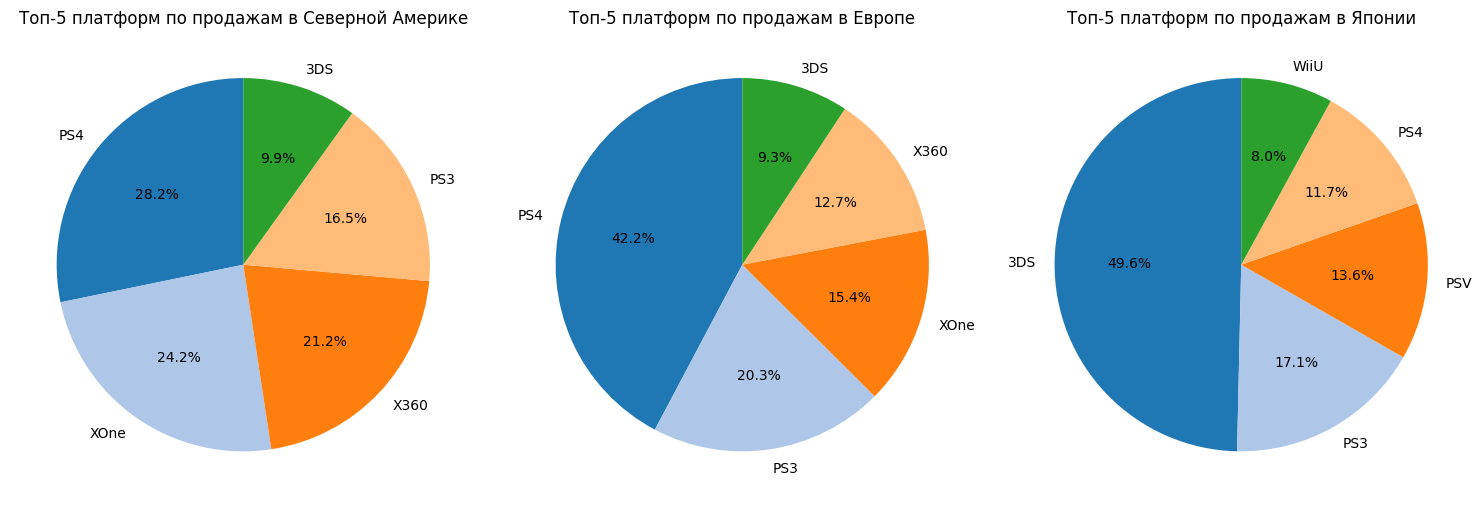

In [45]:
colors = sns.color_palette('tab20')

regions = ['na_sales', 'eu_sales', 'jp_sales']
names = ['Северной Америке', 'Европе', 'Японии']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, name in zip(axes, regions, names):

    data.groupby('platform')[col].sum() \
        .sort_values(ascending=False)[:5] \
        .plot(
            kind='pie',
            autopct='%.1f%%',
            startangle=90,
            ax=ax,
            colors=colors)

    ax.set_ylabel("")
    ax.set_title(f"Топ-5 платформ по продажам в {name}")

plt.tight_layout()
plt.show()

В Северной Америке и Европе чаще покупают игры на платформы от Sony Electronics (PS3, PS4) и Microsoft (XOne, X360). При этом покупатели в Северной Америке отдают предпочтение  Microsoft (45% от продаж), а в Европе популярнее продукция Sony Electronics (62% от продаж).

На японском рынке ситуация другая. Там доминируют платформы от местного производителя Nintendo (58% от продаж).  

#### Самые популярные жанры (топ-5)

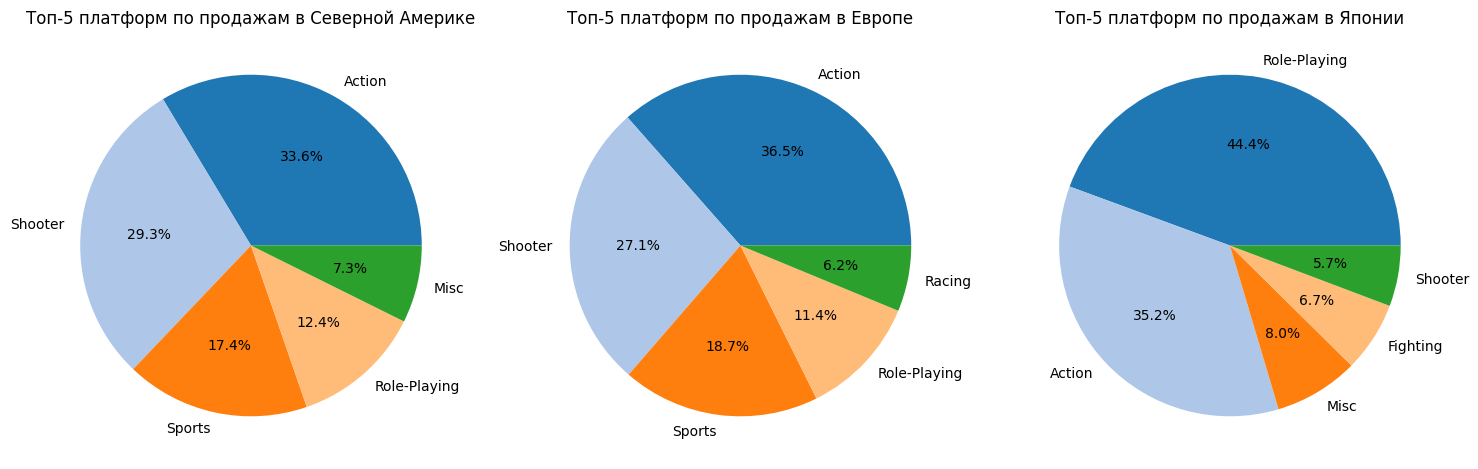

In [46]:
colors = sns.color_palette('tab20')

regions = ['na_sales', 'eu_sales', 'jp_sales']
names = ['Северной Америке', 'Европе', 'Японии']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, name in zip(axes, regions, names):

    data.groupby('genre')[col].sum().sort_values(ascending=False)[:5] \
        .plot(kind='pie',
              autopct='%.1f%%',
              ax=ax,
              colors=colors)

    ax.set_ylabel("")  # убрать подпись слева
    ax.set_title(f"Топ-5 платформ по продажам в {name}")

plt.tight_layout()
plt.show()


Топ европейских жанров похож на пятёрку самых распространённых жанров в Северной Америке: экшен-игры, шутеры, спортивные и ролевые игры. Единственным отличием является наличие в американском топе жанра Misc, а в европейском - Racing.

В Японии 44% рынка занимают ролевые игры. На втором месте Action, а на шутеры приходится всего 5.7% от продаж.

#### Влияет ли рейтинг ESRB на продажи в отдельном регионе?

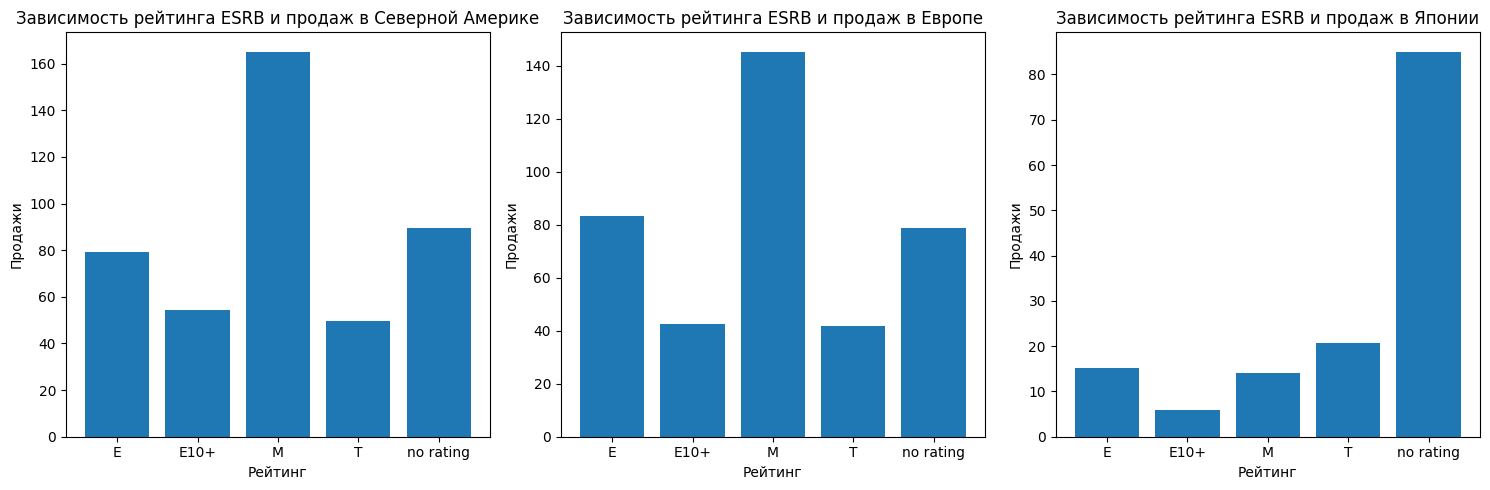

In [47]:
regions = ['na_sales', 'eu_sales', 'jp_sales']
names = ['Северной Америке', 'Европе', 'Японии']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, name in zip(axes, regions, names):

    plot_df = data.groupby('rating')[col].sum()

    ax.bar(plot_df.index, plot_df.values)

    ax.set_title('Зависимость рейтинга ESRB и продаж в ' + name)
    ax.set_xlabel('Рейтинг')
    ax.set_ylabel('Продажи')

plt.tight_layout()
plt.show()

В Северной Америке и Европе наибольшие продажи приходятся на игры с рейтингом M (17+) и E (для всех возрастов). В Японии значительная доля продаж приходится на игры без рейтинга ESRB, что связано с особенностями локального рынка и ограничивает возможности прямого сравнения регионов по этому признаку.

## Проверка гипотез

#### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

H0: Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.

H1: Средние пользовательские рейтинги платформ Xbox One и PC различаются.

- h0: user_score Xbox One = user_score PC

- h1: user_score Xbox One != user_score PC

- alpha = 0.05

In [48]:
xone = data.loc[data['platform']=='XOne','user_score'].dropna()
pc = data.loc[data['platform']=='PC','user_score'].dropna()

print('Среднее первой выборки: ', round(xone.mean(),2))
print('Среднее второй выборки: ', round(pc.mean(),2))
print()
print('Дисперсия первой выборки: ', round(xone.var(),2))
print('Дисперсия второй выборки: ', round(pc.var(),2))

Среднее первой выборки:  6.52
Среднее второй выборки:  6.27

Дисперсия первой выборки:  1.91
Дисперсия второй выборки:  3.04


Проверяем равенство дисперсий, чтобы выбрать параметр equal_var в t-test.

In [49]:
from scipy.stats import levene

stat, p = levene(xone, pc)

if p < 0.05:
    print('Дисперсии различаются → equal_var=False')
else:
    print('Нет оснований считать дисперсии разными → equal_var=True')

Дисперсии различаются → equal_var=False


Для проверки гипотезы используется t-критерий Стьюдента, поскольку необходимо сравнить средние значения двух независимых выборок.

In [50]:
alpha = 0.05

result = st.ttest_ind(xone, pc, equal_var=False)

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.1475959401343046
Не отвергаем нулевую гипотезу


Значение p-value больше уровня статистической значимости, значит, нет основания полагать, что средние пользовательские рейтинги платформ Xbox One и PC различаются. 

#### Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

H0: Средние пользовательские рейтинги жанров Action и Sports одинаковые.

H1: Средние пользовательские рейтинги жанров Action и Sports различаются.

- h0: user_score Action = user_score Sports

- h1: user_score Action != user_score Sports

- alpha = 0.05

In [51]:
action = data.loc[data['genre']=='Action','user_score'].dropna()
sports = data.loc[data['genre']=='Sports','user_score'].dropna()

print('Среднее первой выборки: ', round(action.mean(),2))
print('Среднее второй выборки: ', round(sports.mean(),2))
print()
print('Дисперсия первой выборки: ', round(action.var(),2))
print('Дисперсия второй выборки: ', round(sports.var(),2))

Среднее первой выборки:  6.84
Среднее второй выборки:  5.24

Дисперсия первой выборки:  1.77
Дисперсия второй выборки:  3.18


In [52]:
stat, p = levene(action, sports)

if p < 0.05:
    print('Дисперсии различаются → equal_var=False')
else:
    print('Нет оснований считать дисперсии разными → equal_var=True')

Дисперсии различаются → equal_var=False


In [53]:
alpha = 0.05

result = st.ttest_ind(action, sports, equal_var=False)

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 1.4460039700703936e-20
Отвергаем нулевую гипотезу


Значение p-value меньше уровня статистической значимости, значит, есть основание полагать, что разница между средними пользовательскими рейтингами жанров Action и Sports статистически значима.

## Общие выводы

В ходе исследования были подготовлены данные, обработаны пропуски и рассчитаны суммарные мировые продажи игр. Для дальнейшего анализа был выбран период 2013–2016 годов, поскольку он наиболее актуален для построения прогноза на 2017 год и отражает текущее состояние рынка.

Анализ показал, что наиболее перспективными платформами являются PS4 и Xbox One. Также было установлено, что оценки критиков оказывают заметно большее влияние на продажи игр, чем оценки пользователей. Среди жанров лидерами по продажам являются Action, Shooter и Sports, тогда как жанр Adventure демонстрирует самые низкие показатели.

Предпочтения пользователей различаются по регионам: рынки Северной Америки и Европы во многом схожи, а Япония заметно отличается как по популярным платформам, так и по жанрам. Проверка гипотез показала, что средние пользовательские рейтинги Xbox One и PC статистически не различаются, тогда как рейтинги жанров Action и Sports различаются значимо.

Для рекламной кампании 2017 года наиболее перспективным направлением являются игры для платформ PS4 и XOne, прежде всего в жанрах Action и Shooter. При планировании маркетинговой активности необходимо учитывать региональные различия: предпочтения пользователей Японии существенно отличаются от предпочтений игроков Северной Америки и Европы.